<a href="https://colab.research.google.com/github/MrRichar02/Proyecto-Final-Modelos-2-G04/blob/main/desarrollo-proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Entrenamiento y Evaluación de los Modelos

## Importaciones generales

Asegurese de instalar las dependencias definidas para el proyecto en el `requirements.txt` o el `pyproject.toml`.

Si esta en colab solo necesita instalar la siguiente dependencia

## Importación de dataset usando ucimlrepo(Puede causar error porque parece que dejaron expirar su certificado ssl)

In [45]:
!pip install ucimlrepo

In [46]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

In [47]:

# fetch dataset
online_shoppers_purchasing_intention_dataset = fetch_ucirepo(id=468)

# data (as pandas dataframes)
X = online_shoppers_purchasing_intention_dataset.data.features
y = online_shoppers_purchasing_intention_dataset.data.targets.copy()

online_shoppers_purchasing_intention_dataset['variables']

,name,role,type,demographic,description,units,missing_values
0,Administrative,Feature,Integer,None,None,None,no
1,Administrative_Duration,Feature,Integer,None,None,None,no
2,Informational,Feature,Integer,None,None,None,no
3,Informational_Duration,Feature,Integer,None,None,None,no
4,ProductRelated,Feature,Integer,None,None,None,no
5,ProductRelated_Duration,Feature,Continuous,None,None,None,no
6,BounceRates,Feature,Continuous,None,None,None,no
7,ExitRates,Feature,Continuous,None,None,None,no
8,PageValues,Feature,Integer,None,None,None,no
9,SpecialDay,Feature,Integer,None,None,None,no


## Importación del datset usando wget

In [4]:
import numpy as np
import pandas as pd

In [5]:
!wget https://raw.githubusercontent.com/MrRichar02/Proyecto-Final-Modelos-2-G04/refs/heads/main/online_shoppers.csv

--2026-05-25 14:41:12--  https://raw.githubusercontent.com/MrRichar02/Proyecto-Final-Modelos-2-G04/refs/heads/main/online_shoppers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1921728 (1.8M) [text/plain]
Saving to: ‘online_shoppers.csv’

online_shoppers.csv 100%[===================>]   1.83M  10.2MB/s    in 0.2s    

2026-05-25 14:41:14 (10.2 MB/s) - ‘online_shoppers.csv’ saved [1921728/1921728]



In [6]:
# cargar archivo csv
df = pd.read_csv("online_shoppers.csv")

# separar variables predictoras y variable objetivo
X = df.drop(columns=["Revenue"])
y = df[["Revenue"]].copy()

## Análisis variables

De acuerdo a la descripción del dataset disponible en UC Irvine, se concluye que las siguientes variables son categóricas.

- Revenue
- Weekend
- VisitorType
- TrafficType
- Region
- Browser
- OperatingSystems
- Month

In [7]:
vars_cat = ["Weekend","VisitorType","TrafficType","Region","Browser","OperatingSystems","Month"]
print("Revenue: ",np.unique(y["Revenue"]))
for i in vars_cat:
    print(i+": ", np.unique(X[i]))

Revenue:  [False  True]
Weekend:  [False  True]
VisitorType:  ['New_Visitor' 'Other' 'Returning_Visitor']
TrafficType:  [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Region:  [1 2 3 4 5 6 7 8 9]
Browser:  [ 1  2  3  4  5  6  7  8  9 10 11 12 13]
OperatingSystems:  [1 2 3 4 5 6 7 8]
Month:  ['Aug' 'Dec' 'Feb' 'Jul' 'Jun' 'Mar' 'May' 'Nov' 'Oct' 'Sep']


## Descripción de las variables numéricas

In [8]:
num_cols = ['Administrative','Administrative_Duration','Informational',
            'Informational_Duration','ProductRelated','ProductRelated_Duration',
            'BounceRates','ExitRates','PageValues','SpecialDay']

In [9]:
for i in num_cols:
    print(i+": ", X[i].dtype)

Administrative:  float64
Administrative_Duration:  float64
Informational:  float64
Informational_Duration:  float64
ProductRelated:  float64
ProductRelated_Duration:  float64
BounceRates:  float64
ExitRates:  float64
PageValues:  float64
SpecialDay:  float64


In [10]:
X[num_cols].describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.369992,188.295315,0.438200,18.153253,12.999838,1304.336973,0.272132,0.218265,7.626409,0.084185
std,2.828056,366.430474,0.783344,49.295026,7.759546,1760.549049,0.175148,0.147070,16.504281,0.234057
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.189142,0.000437,0.000000,0.000560,0.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,266.327440,0.130908,0.103398,1.039758,0.000000
50%,1.000000,57.649088,0.000000,0.000000,11.000000,716.235937,0.243016,0.197075,2.595851,0.000000
75%,3.000000,210.554445,1.000000,9.994393,17.000000,1659.781555,0.386561,0.313204,6.002672,0.000000
max,26.000000,7706.622831,8.000000,745.467870,57.000000,28616.053986,0.912550,0.774382,264.335041,1.000000


## Preparación encoding variables

### One-hot Encoding

In [48]:
X = pd.get_dummies(X, columns=['OperatingSystems'], prefix="OperatingSytem_", dtype=int)
X = pd.get_dummies(X, columns=['Browser'], prefix="Browser_", dtype=int)
X = pd.get_dummies(X, columns=['Region'], prefix="Region_", dtype=int)
X = pd.get_dummies(X, columns=['TrafficType'], prefix="TrafficType_", dtype=int)
X = pd.get_dummies(X, columns=['VisitorType'], prefix="VisitorType_", dtype=int)

### Label Encoding si se importo el dataset usando wget

In [12]:
X['Month'] = X['Month'].map({
    'Feb': 1,
    'Mar': 2,
    'May': 3,
    'Jun': 4,
    'Jul': 5,
    'Aug': 6,
    'Sep': 7,
    'Oct': 8,
    'Nov': 9,
    'Dec': 10
})

### Label Encoding si se importo el dataset usando ucimlrepo

In [49]:
X['Month'] = X['Month'].map({
    'Feb': 1,
    'Mar': 2,
    'May': 3,
    'June': 4,
    'Jul': 5,
    'Aug': 6,
    'Sep': 7,
    'Oct': 8,
    'Nov': 9,
    'Dec': 10
})

### Convertir valores tipos Boolean a int(0 y 1)

In [50]:
X['Weekend'] = X['Weekend'].astype(int)

In [51]:
y['Revenue'] = y['Revenue'].astype(int)

### Nuevos shapes

In [52]:
X.shape, y.shape


((12330, 65), (12330, 1))

## Separación de test y train y aplicación de SMOTE

### Dividimos el dataset en test y train, asignando un 20% para el test

In [53]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Aplicación de SMOTE para generar muestras artificiales de la clase minoritaria de manera demostrativa para explorar los efectos de SMOTE

#### Se obtiene la relación entre la clase positiva y la clase negativa

In [18]:
clase_negativo, clase_positivo = y_train.value_counts()
(clase_positivo)/(clase_negativo)

0.2024868950384006

### Primer porcentaje: Se aumenta la proporción de un 18% a un 20%

In [55]:
# Aplicar SMOTE SOLO al train
smote = SMOTE(random_state=42, sampling_strategy=0.22)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [56]:
print(y_train.value_counts())
print(y_train_resampled.value_counts())

Revenue
0          8338
1          1526
Name: count, dtype: int64
Revenue
0          8338
1          1834
Name: count, dtype: int64


#### Segundo porcentaje: Se aumenta la proporción de un 18% a un 30%

In [57]:
# Aplicar SMOTE SOLO al train
smote1 = SMOTE(random_state=42, sampling_strategy=0.3)

X_train_resampled1, y_train_resampled1 = smote1.fit_resample(
    X_train,
    y_train
)

In [58]:
print(y_train.value_counts())
print(y_train_resampled1.value_counts())

Revenue
0          8338
1          1526
Name: count, dtype: int64
Revenue
0          8338
1          2501
Name: count, dtype: int64


#### Tercer porcentaje: Se aumenta la proporción de un 18% a un 40%

In [59]:
# Aplicar SMOTE SOLO al train
smote2 = SMOTE(random_state=42, sampling_strategy=0.4)

X_train_resampled2, y_train_resampled2 = smote2.fit_resample(
    X_train,
    y_train
)

In [60]:
print(y_train.value_counts())
print(y_train_resampled2.value_counts())

Revenue
0          8338
1          1526
Name: count, dtype: int64
Revenue
0          8338
1          3335
Name: count, dtype: int64


### Definición de metodología de validación

In [61]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

## Entrenamiento de modelos usando pipeline con normalización, SMOTE y malla de hiperparametros

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.svm import SVC

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [26]:
y_train = y_train.values.ravel()

### Random Forest(Jenny)

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import numpy as np

In [64]:
# PIPELINE  (scaler → SMOTE → RandomForest)
# El StandardScaler no es estrictamente necesario para RF, pero se mantiene para ser consistente con los demás modelos del proyecto y porque SMOTE opera mejor con datos escalados.

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.3)),   # valor base; GridSearch lo variará
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,          # usar todos los núcleos disponibles
        class_weight='balanced'  # refuerzo adicional para clase minoritaria (Revenue=1)
    ))
])


In [65]:
# Parámetros clave para RF:
#   n_estimators   → número de árboles; más árboles = más estable, más lento
#   max_depth      → profundidad máxima; None = crece hasta hojas puras (riesgo overfitting)
#   min_samples_split → muestras mínimas para dividir un nodo (regularización)
#   min_samples_leaf  → muestras mínimas en hoja (regularización)
#   max_features   → features evaluados en cada split; 'sqrt' es estándar para clasificación
#   sampling_strategy → proporción SMOTE (clase_positiva / clase_negativa)

param_grid_rf = {
    # SMOTE (evaluar los 3 porcentajes)
    'smote__sampling_strategy': [0.22, 0.3, 0.4],
    'smote__k_neighbors': [3, 5, 7],

    # RF — solo los más influyentes, valores fijos para el resto
    'classifier__n_estimators': [200],        # fijo, suficiente para estabilidad
    'classifier__max_depth': [10, 20],        # el más importante a explorar
    'classifier__min_samples_leaf': [1, 4],   # segundo más importante
    'classifier__max_features': ['sqrt'],     # fijo, es el estándar para clasificación
}

In [66]:
# GRID SEARCH CON VALIDACIÓN CRUZADA ESTRATIFICADA
# Se usa roc_auc (igual que en la evaluación final del proyecto,
# ver: scoring = "roc_auc" y roc_auc_score en la sección de LR)

from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=cv_strategy,         # StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scoring='roc_auc',      # métrica principal del proyecto
    n_jobs=-1,
    verbose=2,
    error_score='raise',
    refit=True              # refitea automáticamente con los mejores parámetros
)

In [67]:
# Entrenamiento
grid_rf.fit(X_train, y_train)

Fitting 10 folds for each of 36 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote',
                                        SMOTE(random_state=42,
                                              sampling_strategy=0.3)),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [10, 20],
                         'classifier__max_features': ['sqrt'],
                         'classifier__min_samples_leaf': [1, 4],
                         'classifier__n_estimators': [200],
                         'smote__k_neighbors': [3, 5, 7],
                         'smote__sampling_strategy': [0.22, 0.3, 0.4]},
             scoring='roc_auc', verbose=2)

In [68]:
# RESULTADOS DEL GRID SEARCH
print("=" * 60)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
print("=" * 60)
for param, value in grid_rf.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMejor ROC-AUC (CV en train): {grid_rf.best_score_:.4f}")

MEJORES HIPERPARÁMETROS ENCONTRADOS:
  classifier__max_depth: 20
  classifier__max_features: sqrt
  classifier__min_samples_leaf: 4
  classifier__n_estimators: 200
  smote__k_neighbors: 7
  smote__sampling_strategy: 0.22

Mejor ROC-AUC (CV en train): 0.9281


In [69]:
# VALIDACIÓN CRUZADA FINAL CON EL MEJOR PIPELINE
scores_rf = cross_val_score(
    grid_rf.best_estimator_,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

print(f"\nROC-AUC por fold (CV):")
print(np.round(scores_rf, 4))
print(f"Media:  {scores_rf.mean():.4f}")
print(f"Std:    {scores_rf.std():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi


ROC-AUC por fold (CV):
[0.9239 0.9308 0.9124 0.9364 0.9107 0.9331 0.9413 0.9316 0.9373 0.923 ]
Media:  0.9281
Std:    0.0098


In [70]:
# EVALUACIÓN FINAL EN TEST
best_rf = grid_rf.best_estimator_
best_rf.fit(X_train, y_train)

y_pred_prob_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf = best_rf.predict(X_test)

roc_auc_test = roc_auc_score(y_test, y_pred_prob_rf)

print("\n" + "=" * 60)
print(f"ROC-AUC EN TEST: {roc_auc_test:.4f}")
print("=" * 60)

print("\nReporte de clasificación (threshold=0.5):")
print(classification_report(y_test, y_pred_rf, target_names=['No compra (0)', 'Compra (1)']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



ROC-AUC EN TEST: 0.9183

Reporte de clasificación (threshold=0.5):
               precision    recall  f1-score   support

No compra (0)       0.95      0.91      0.93      2084
   Compra (1)       0.59      0.75      0.66       382

     accuracy                           0.88      2466
    macro avg       0.77      0.83      0.79      2466
 weighted avg       0.90      0.88      0.89      2466

Matriz de confusión:
[[1887  197]
 [  97  285]]


In [71]:
#IMPORTANCIA DE FEATURES
import pandas as pd

feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'f{i}' for i in range(X_train.shape[1])]

# Extraer el RF del pipeline final
rf_model = best_rf.named_steps['classifier']

importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(15)

print("\nTop 15 features más importantes:")
print(top_features.round(4).to_string())



Top 15 features más importantes:
PageValues                        0.4533
ExitRates                         0.0883
ProductRelated_Duration           0.0770
ProductRelated                    0.0593
Month                             0.0494
BounceRates                       0.0473
Administrative_Duration           0.0441
Administrative                    0.0372
Informational_Duration            0.0154
Informational                     0.0139
TrafficType__2                    0.0125
VisitorType__Returning_Visitor    0.0092
SpecialDay                        0.0070
Weekend                           0.0066
VisitorType__New_Visitor          0.0062


# Curva de Aprendizaje

(0.75, 1.01)

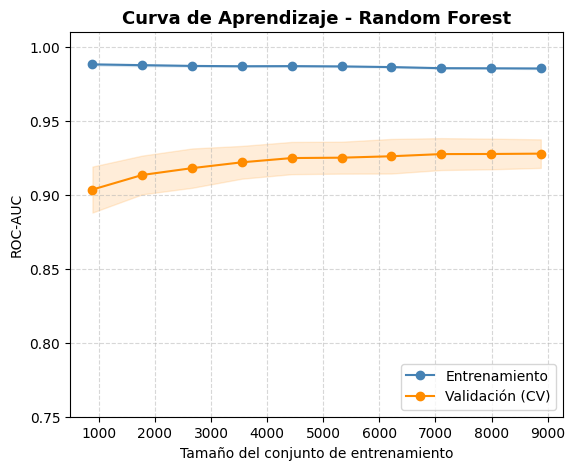

In [72]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)

train_sizes, train_scores, val_scores = learning_curve(
    grid_rf.best_estimator_,
    X_train, y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

ax1 = fig.add_subplot(gs[0])
ax1.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Entrenamiento')
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
ax1.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validación (CV)')
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='darkorange')
ax1.set_title('Curva de Aprendizaje - Random Forest', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tamaño del conjunto de entrenamiento')
ax1.set_ylabel('ROC-AUC')
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_ylim(0.75, 1.01)

# Matriz de confusión

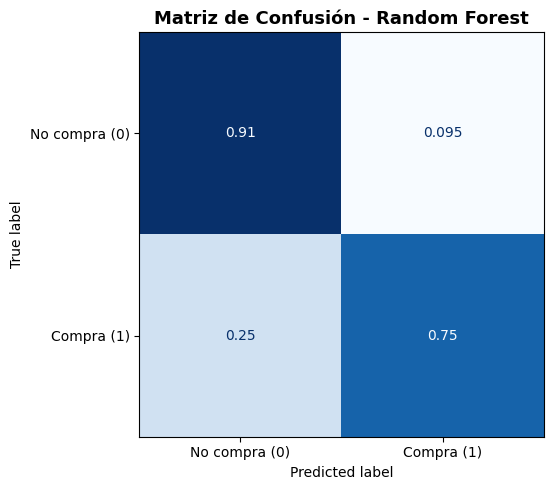

In [76]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)

cm = confusion_matrix(y_test, y_pred_rf,normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No compra (0)', 'Compra (1)'])

ax2 = fig.add_subplot(gs[1])
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Matriz de Confusión - Random Forest', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('rf_curva_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### XGBoost(Jenny)

In [77]:
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import numpy as np

In [78]:
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.3)),
    ('classifier', XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',   # evita warning interno de XGBoost
        verbosity=0              # silencia logs innecesarios
    ))
])

# MALLA DE HIPERPARÁMETROS

In [79]:
param_grid_xgb = {
    # SMOTE — los 3 porcentajes requeridos
    'smote__sampling_strategy': [0.22, 0.3, 0.4],
    'smote__k_neighbors': [3, 5, 7],

    # XGBoost — parámetros más influyentes
    'classifier__n_estimators': [200],
    'classifier__max_depth': [3, 6],          # profundidad del árbol base
    'classifier__learning_rate': [0.05, 0.1], # tasa de aprendizaje
    'classifier__subsample': [0.8],           # fracción de muestras por árbol
    'classifier__colsample_bytree': [0.8],    # fracción de features por árbol
}

#GRID SEARCH

In [80]:
grid_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    refit=True
)

In [81]:
grid_xgb.fit(X_train, y_train)

Fitting 10 folds for each of 36 candidates, totalling 360 fits


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote',
                                        SMOTE(random_state=42,
                                              sampling_strategy=0.3)),
                                       ('classifier',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_r...
                                                      n_estimators=None,
                                                      n_jobs=-1,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__colsample_bytree': [0.8],
                         'classifier__learning_rate': [0.05, 0.1],
                         'classifier__max_depth': [3, 6],
                         'classifier__n_estimators': [200],
                         'classifier__subsample': [0.8],
                         'smote__k_neighbors': [3, 5, 7],
                         'smote__sampling_strategy': [0.22, 0.3, 0.4]},
             scoring='roc_auc', verbose=2)

# RESULTADOS

In [82]:
print("=" * 60)
print("MEJORES HIPERPARÁMETROS:")
print("=" * 60)
for param, value in grid_xgb.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMejor ROC-AUC (CV en train): {grid_xgb.best_score_:.4f}")

MEJORES HIPERPARÁMETROS:
  classifier__colsample_bytree: 0.8
  classifier__learning_rate: 0.05
  classifier__max_depth: 6
  classifier__n_estimators: 200
  classifier__subsample: 0.8
  smote__k_neighbors: 3
  smote__sampling_strategy: 0.22

Mejor ROC-AUC (CV en train): 0.9343


# EVALUACIÓN FINAL EN TEST


In [83]:
best_xgb = grid_xgb.best_estimator_
best_xgb.fit(X_train, y_train)

y_pred_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = best_xgb.predict(X_test)

roc_auc_test = roc_auc_score(y_test, y_pred_prob_xgb)

print("\n" + "=" * 60)
print(f"ROC-AUC EN TEST: {roc_auc_test:.4f}")
print("=" * 60)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb, target_names=['No compra (0)', 'Compra (1)']))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_xgb))


ROC-AUC EN TEST: 0.9299

Reporte de clasificación:
               precision    recall  f1-score   support

No compra (0)       0.93      0.95      0.94      2084
   Compra (1)       0.70      0.63      0.66       382

     accuracy                           0.90      2466
    macro avg       0.82      0.79      0.80      2466
 weighted avg       0.90      0.90      0.90      2466

Matriz de confusión:
[[1981  103]
 [ 141  241]]


# Curva de Aprendizaje

(0.75, 1.01)

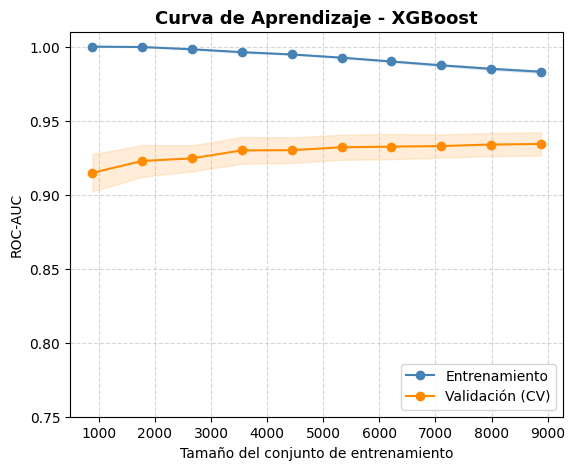

In [84]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)

train_sizes, train_scores, val_scores = learning_curve(
    grid_xgb.best_estimator_,
    X_train, y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

ax1 = fig.add_subplot(gs[0])
ax1.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Entrenamiento')
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
ax1.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validación (CV)')
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='darkorange')
ax1.set_title('Curva de Aprendizaje - XGBoost', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tamaño del conjunto de entrenamiento')
ax1.set_ylabel('ROC-AUC')
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_ylim(0.75, 1.01)

#MATRIZ DE CONFUSIÓN

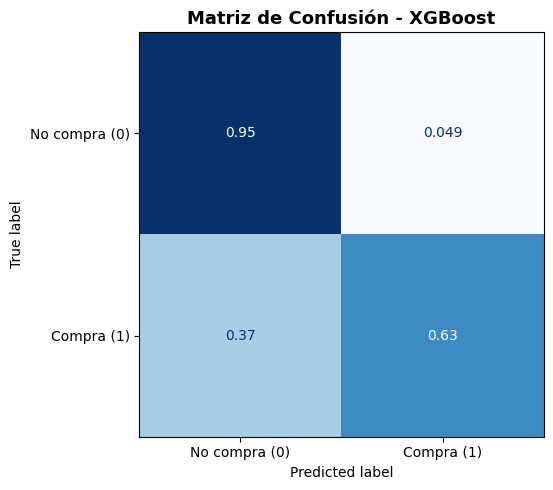


ROC-AUC promedio CV : 0.9342 ± 0.0078
ROC-AUC en test     : 0.9299

Verdaderos Negativos : 0.9505758157389635  |  Falsos Positivos : 0.049424184261036466
Falsos Negativos     : 0.36910994764397903  |  Verdaderos Positivos: 0.6308900523560209


In [87]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)

cm = confusion_matrix(y_test, y_pred_xgb, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No compra (0)', 'Compra (1)'])

ax2 = fig.add_subplot(gs[1])
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Matriz de Confusión - XGBoost', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('xgb_curva_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 3. RESUMEN NUMÉRICO
# ------------------------------------------------------------
print(f"\nROC-AUC promedio CV : {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
print(f"ROC-AUC en test     : {roc_auc_score(y_test, y_pred_prob_xgb):.4f}")
print(f"\nVerdaderos Negativos : {cm[0,0]}  |  Falsos Positivos : {cm[0,1]}")
print(f"Falsos Negativos     : {cm[1,0]}  |  Verdaderos Positivos: {cm[1,1]}")

### MLP (Santiago)

In [ ]:
pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', MLPClassifier(
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
param_grid_mlp = {

    'smote__sampling_strategy':[0.22,0.3],
    'smote__k_neighbors':[5],

    'classifier__hidden_layer_sizes':[
        (50,),
        (100,)
    ],

    'classifier__activation':[
        'relu'
    ],

    'classifier__alpha':[
        0.0001,
        0.001
    ],

    'classifier__learning_rate_init':[
        0.001,
        0.01
    ]
}

In [ ]:
grid_mlp = GridSearchCV(
    estimator=pipeline_mlp,
    param_grid=param_grid_mlp,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_mlp.fit(X_train,y_train)

Fitting 10 folds for each of 16 candidates, totalling 160 fits


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier',
                                        MLPClassifier(max_iter=1000,
                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__activation': ['relu'],
                         'classifier__alpha': [0.0001, 0.001],
                         'classifier__hidden_layer_sizes': [(50,), (100,)],
                         'classifier__learning_rate_init': [0.001, 0.01],
                         'smote__k_neighbors': [5],
                         'smote__sampling_strategy': [0.22, 0.3]},
             scoring='roc_auc', verbose=2)

### Mejores hiperparámetros

In [ ]:
grid_mlp.best_score_

np.float64(0.8578821040642243)

In [ ]:
print(grid_mlp.best_params_)

{'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (100,), 'classifier__learning_rate_init': 0.01, 'smote__k_neighbors': 5, 'smote__sampling_strategy': 0.22}


### Intervalos de confianza del Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score
scores_mlp = cross_val_score(
    grid_mlp.best_estimator_,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)
print(f"ROC-AUC por fold Cross-Validation:")
print(np.round(scores_mlp, 4))
print(f"Media:  {scores_mlp.mean():.4f}")
print(f"Std:    {scores_mlp.std():.4f}")

ROC-AUC por fold Cross-Validation:
[0.8736 0.8342 0.8405 0.8229 0.8585 0.8666 0.8582 0.8683 0.8682 0.8788]
Media:  0.8570
Std:    0.0175


### Resultados en test

In [ ]:
best_mlp = grid_mlp.best_estimator_

best_mlp.fit(X_train,y_train)

y_pred_prob_mlp = best_mlp.predict_proba(X_test)[:,1]
y_pred_mlp = best_mlp.predict(X_test)

print("ROC-AUC TEST:")
print(roc_auc_score(y_test,y_pred_prob_mlp))

print(classification_report(y_test,y_pred_mlp))
print(confusion_matrix(y_test,y_pred_mlp))

ROC-AUC TEST:
0.8641227024137506
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2051
           1       0.72      0.67      0.70       415

    accuracy                           0.90      2466
   macro avg       0.83      0.81      0.82      2466
weighted avg       0.90      0.90      0.90      2466

[[1941  110]
 [ 135  280]]


### Resultados en train

In [ ]:
best_mlp.fit(X_train, y_train)
y_pred_prob_train_mlp = best_mlp.predict_proba(X_train)[:, 1]
y_pred_train_mlp = best_mlp.predict(X_train)
print("ROC-AUC TRAIN:")
print(roc_auc_score(y_train, y_pred_prob_train_mlp))
print(classification_report(y_train, y_pred_train_mlp))

ROC-AUC TRAIN:
0.9998019109174534
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8203
           1       1.00      1.00      1.00      1661

    accuracy                           1.00      9864
   macro avg       1.00      1.00      1.00      9864
weighted avg       1.00      1.00      1.00      9864



### Nombres de clases en el classification_report

In [ ]:
print(classification_report(
    y_test, y_pred_mlp,
    target_names=['No compra (0)', 'Compra (1)']
))

               precision    recall  f1-score   support

No compra (0)       0.93      0.95      0.94      2051
   Compra (1)       0.72      0.67      0.70       415

     accuracy                           0.90      2466
    macro avg       0.83      0.81      0.82      2466
 weighted avg       0.90      0.90      0.90      2466



### Matriz de confusión

<Figure size 600x600 with 0 Axes>

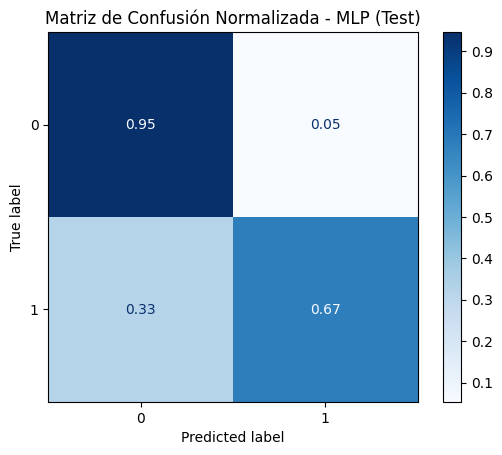

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# MATRIZ DE CONFUSIÓN NORMALIZADA EN TEST

# predicciones del mejor modelo
y_test_pred = best_mlp.predict(X_test)

# matriz de confusión normalizada
cm = confusion_matrix(
    y_test,
    y_test_pred,
    normalize='true'
)

# visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 6))

disp.plot(
    cmap='Blues',
    values_format='.2f'
)

plt.title('Matriz de Confusión Normalizada - MLP (Test)')

plt.show()

### Curva de aprendizaje

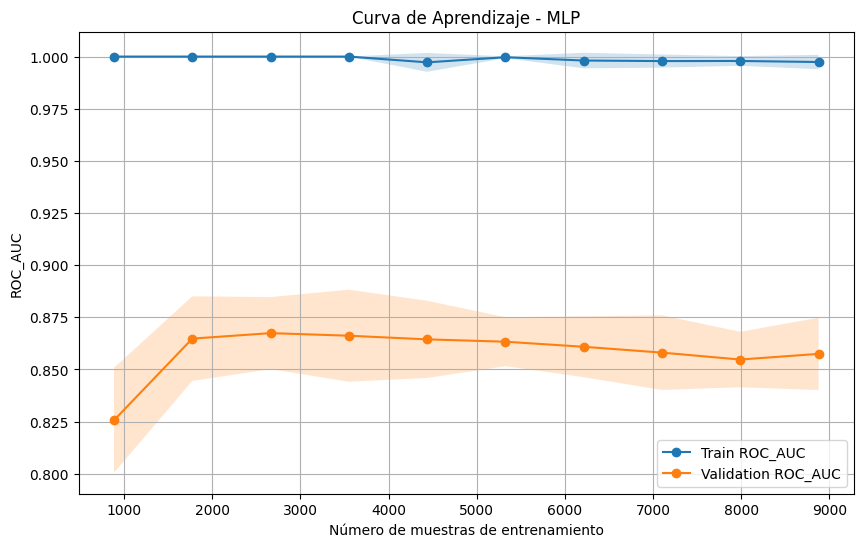

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_mlp,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Train ROC_AUC'
)
plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation ROC_AUC'
)
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)
plt.xlabel('Número de muestras de entrenamiento')
plt.ylabel('ROC_AUC')
plt.title('Curva de Aprendizaje - MLP')
plt.legend()
plt.grid(True)
plt.show()

### K-means(Santiago)


#### Implementación de K-Means como modelo de clasificación mediante asignación por clase mayoritaria

In [ ]:
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class KMeansClassifier(ClassifierMixin, BaseEstimator):

    _estimator_type = "classifier"

    def __init__(self, n_clusters=2, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state

    def fit(self, X, y):

        y = np.asarray(y).astype(int)

        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=10
        )

        clusters = self.kmeans_.fit_predict(X)

        self.cluster_labels_ = {}

        for c in np.unique(clusters):

            mask = (clusters == c)

            self.cluster_labels_[c] = np.bincount(
                y[mask]
            ).argmax()

        self.classes_ = np.array([0,1])

        return self

    def predict(self, X):

        clusters = self.kmeans_.predict(X)

        return np.array([
            self.cluster_labels_[c]
            for c in clusters
        ])

    def predict_proba(self, X):

        preds = self.predict(X)

        probs = np.zeros((len(preds),2))

        probs[:,0] = 1-preds
        probs[:,1] = preds

        return probs

In [ ]:
pipeline_kmeans = Pipeline([

    ('scaler', StandardScaler()),

    ('smote', SMOTE(random_state=42)),

    ('classifier', KMeansClassifier())
])

In [ ]:
param_grid_kmeans = {

    'smote__sampling_strategy': [
        0.22,
        0.3,
        0.4
    ],

    'smote__k_neighbors': [
        3,
        5,
        7
    ],

    'classifier__n_clusters': [
        2,
        3,
        4,
        5
    ]
}

In [ ]:
grid_kmeans = GridSearchCV(
    estimator=pipeline_kmeans,
    param_grid=param_grid_kmeans,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)

In [ ]:
grid_kmeans.fit(X_train,y_train)

Fitting 10 folds for each of 36 candidates, totalling 360 fits


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             error_score='raise',
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier', KMeansClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__n_clusters': [2, 3, 4, 5],
                         'smote__k_neighbors': [3, 5, 7],
                         'smote__sampling_strategy': [0.22, 0.3, 0.4]},
             scoring='roc_auc', verbose=2)

### Mejores hiperparámetros

In [ ]:
grid_kmeans.best_score_

np.float64(0.5135542168674698)

In [ ]:
print(grid_kmeans.best_params_)

{'classifier__n_clusters': 3, 'smote__k_neighbors': 7, 'smote__sampling_strategy': 0.4}


### Intervalos de confianza del Cross-Validation

In [ ]:
scores_kmeans = cross_val_score(
    grid_kmeans.best_estimator_,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)
print(f"ROC-AUC por fold Cross-Validation:")
print(np.round(scores_kmeans, 4))
print(f"Media:  {scores_kmeans.mean():.4f}")
print(f"Std:    {scores_kmeans.std():.4f}")

ROC-AUC por fold Cross-Validation:
[0.5    0.5    0.5    0.5    0.5    0.6355 0.5    0.5    0.5    0.5   ]
Media:  0.5136
Std:    0.0407


### Resultados en train

In [ ]:
y_pred_prob_train_kmeans = best_kmeans.predict_proba(X_train)[:, 1]
y_pred_train_kmeans = best_kmeans.predict(X_train)
print("ROC-AUC TRAIN:")
print(roc_auc_score(y_train, y_pred_prob_train_kmeans))
print(classification_report(y_train, y_pred_train_kmeans,
      target_names=['No compra (0)', 'Compra (1)']))

ROC-AUC TRAIN:
0.5
               precision    recall  f1-score   support

No compra (0)       0.83      1.00      0.91      8203
   Compra (1)       0.00      0.00      0.00      1661

     accuracy                           0.83      9864
    macro avg       0.42      0.50      0.45      9864
 weighted avg       0.69      0.83      0.76      9864



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Resultados en test

In [ ]:
best_kmeans = grid_kmeans.best_estimator_

best_kmeans.fit(X_train,y_train)

y_pred_prob_kmeans = best_kmeans.predict_proba(X_test)[:,1]
y_pred_kmeans = best_kmeans.predict(X_test)

print("ROC-AUC TEST:")
print(
    roc_auc_score(
        y_test,
        y_pred_prob_kmeans
    )
)

print(
    classification_report(
        y_test,
        y_pred_kmeans
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_kmeans
    )
)

ROC-AUC TEST:
0.5
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      2051
           1       0.00      0.00      0.00       415

    accuracy                           0.83      2466
   macro avg       0.42      0.50      0.45      2466
weighted avg       0.69      0.83      0.76      2466

[[2051    0]
 [ 415    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Nombres de clases en el classification_report

In [ ]:
print(classification_report(
    y_test,
    y_pred_kmeans,
    target_names=['No compra (0)', 'Compra (1)']
))

               precision    recall  f1-score   support

No compra (0)       0.83      1.00      0.91      2051
   Compra (1)       0.00      0.00      0.00       415

     accuracy                           0.83      2466
    macro avg       0.42      0.50      0.45      2466
 weighted avg       0.69      0.83      0.76      2466



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Matriz de confusión

<Figure size 600x600 with 0 Axes>

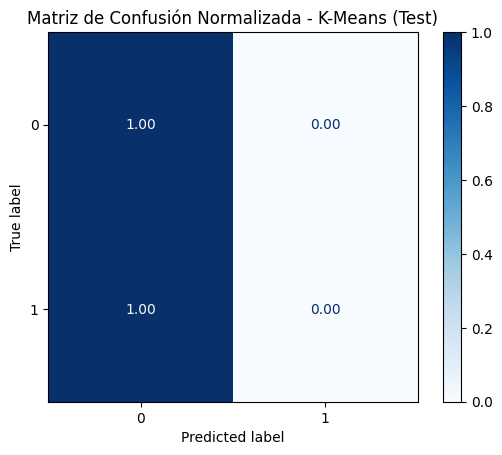

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# MATRIZ DE CONFUSIÓN NORMALIZADA EN TEST
# predicciones del mejor modelo
y_test_pred = best_kmeans.predict(X_test)
# matriz de confusión normalizada
cm = confusion_matrix(
    y_test,
    y_test_pred,
    normalize='true'
)
# visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6, 6))
disp.plot(
    cmap='Blues',
    values_format='.2f'
)
plt.title('Matriz de Confusión Normalizada - K-Means (Test)')
plt.show()

### Curva de aprendizaje

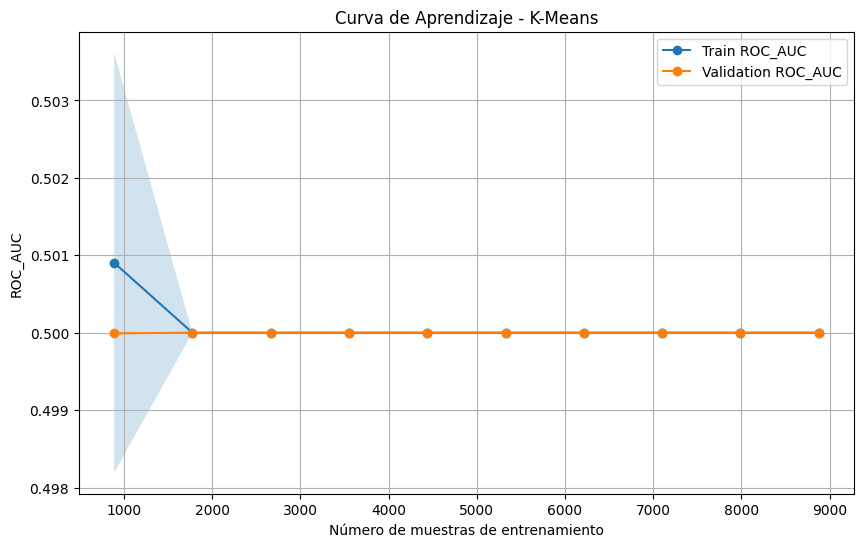

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_kmeans,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)
# medias
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Train ROC_AUC'
)
plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation ROC_AUC'
)
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)
plt.xlabel('Número de muestras de entrenamiento')
plt.ylabel('ROC_AUC')
plt.title('Curva de Aprendizaje - K-Means')
plt.legend()
plt.grid(True)
plt.show()

### KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', KNeighborsClassifier())
])

In [ ]:
param_grid_knn = {
    'smote__sampling_strategy': [0.22, 0.3, 0.4],
    'classifier__n_neighbors': [3, 5, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

In [ ]:
grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_knn.fit(X_train, y_train)

Fitting 10 folds for each of 36 candidates, totalling 360 fits


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'classifier__metric': ['euclidean', 'manhattan'],
                         'classifier__n_neighbors': [3, 5, 11],
                         'classifier__weights': ['uniform', 'distance'],
                         'smote__sampling_strategy': [0.22, 0.3, 0.4]},
             scoring='roc_auc', verbose=2)

### Mejores hiperparámetros

In [ ]:
grid_knn.best_score_

np.float64(0.6881612706611717)

In [ ]:
print(grid_knn.best_params_)

{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'distance', 'smote__sampling_strategy': 0.22}


### Intervalos de confianza del Cross-Validation

In [ ]:
scores_knn = cross_val_score(
    grid_knn.best_estimator_,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)
print(f"ROC-AUC por fold Cross-Validation:")
print(np.round(scores_knn, 4))
print(f"Media:  {scores_knn.mean():.4f}")
print(f"Std:    {scores_knn.std():.4f}")

ROC-AUC por fold Cross-Validation:
[0.7063 0.6471 0.6715 0.6753 0.6858 0.6851 0.7314 0.707  0.7026 0.6696]
Media:  0.6882
Std:    0.0229


### Resultados en train

In [ ]:
best_knn = grid_knn.best_estimator_
best_knn.fit(X_train, y_train)
y_pred_prob_train_knn = best_knn.predict_proba(X_train)[:, 1]
y_pred_train_knn = best_knn.predict(X_train)
print("ROC-AUC TRAIN:")
print(roc_auc_score(y_train, y_pred_prob_train_knn))
print(classification_report(y_train, y_pred_train_knn,
      target_names=['No compra (0)', 'Compra (1)']))

ROC-AUC TRAIN:
1.0
               precision    recall  f1-score   support

No compra (0)       1.00      1.00      1.00      8203
   Compra (1)       1.00      1.00      1.00      1661

     accuracy                           1.00      9864
    macro avg       1.00      1.00      1.00      9864
 weighted avg       1.00      1.00      1.00      9864



### Resultados en test

In [ ]:
y_pred_prob_knn = best_knn.predict_proba(X_test)[:, 1]
y_pred_knn = best_knn.predict(X_test)
print("ROC-AUC TEST:")
print(roc_auc_score(y_test, y_pred_prob_knn))
print(classification_report(y_test, y_pred_knn,
      target_names=['No compra (0)', 'Compra (1)']))

ROC-AUC TEST:
0.6820557706202676
               precision    recall  f1-score   support

No compra (0)       0.84      1.00      0.91      2051
   Compra (1)       0.86      0.04      0.08       415

     accuracy                           0.84      2466
    macro avg       0.85      0.52      0.50      2466
 weighted avg       0.84      0.84      0.77      2466



### Nombres de clases en el classification_report

In [ ]:
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=['No compra (0)', 'Compra (1)']
))

               precision    recall  f1-score   support

No compra (0)       0.84      1.00      0.91      2051
   Compra (1)       0.86      0.04      0.08       415

     accuracy                           0.84      2466
    macro avg       0.85      0.52      0.50      2466
 weighted avg       0.84      0.84      0.77      2466



### Matriz de confusión

<Figure size 600x600 with 0 Axes>

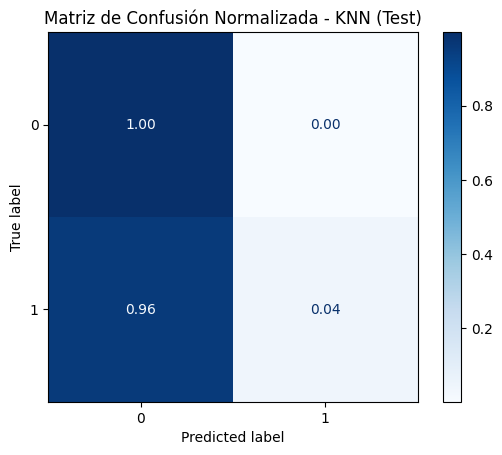

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# MATRIZ DE CONFUSIÓN NORMALIZADA EN TEST
# predicciones del mejor modelo
y_test_pred = best_knn.predict(X_test)
# matriz de confusión normalizada
cm = confusion_matrix(
    y_test,
    y_test_pred,
    normalize='true'
)
# visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(6, 6))
disp.plot(
    cmap='Blues',
    values_format='.2f'
)
plt.title('Matriz de Confusión Normalizada - KNN (Test)')
plt.show()

### Curva de aprendizaje

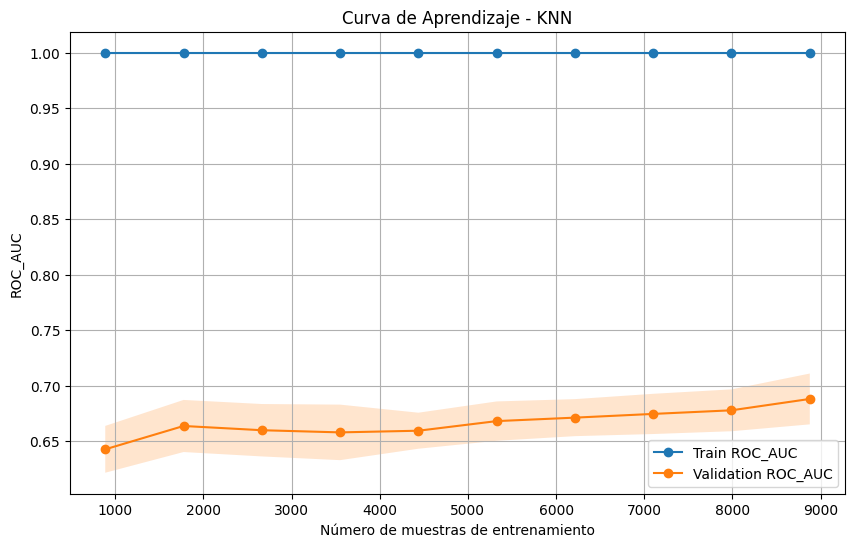

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_knn,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)
# medias
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Train ROC_AUC'
)
plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation ROC_AUC'
)
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)
plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)
plt.xlabel('Número de muestras de entrenamiento')
plt.ylabel('ROC_AUC')
plt.title('Curva de Aprendizaje - KNN')
plt.legend()
plt.grid(True)
plt.show()

### SVM(Ricardo)

In [ ]:
pipeline_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
])

In [ ]:
param_grid_svc = [
  {
      'smote__sampling_strategy': [0.22, 0.3],
      'svc__kernel': ['linear'],
      'svc__C': [0.01, 0.1, 1]
  },
  {
      'smote__sampling_strategy': [0.22, 0.3],
      'svc__kernel': ['rbf'],
      'svc__C': [0.01, 0.1, 1],
      'svc__gamma': ['scale', 'auto', 0.01, 0.1],
  }

]

In [ ]:
grid_svc = GridSearchCV(
    estimator=pipeline_svc,
    param_grid=param_grid_svc,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [ ]:
grid_svc.fit(X_train,y_train)

Fitting 10 folds for each of 30 candidates, totalling 300 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'smote__sampling_strategy': [0.22, 0.3], 'svc__C': [0.01, 0.1, ...], 'svc__kernel': ['linear']}, {'smote__sampling_strategy': [0.22, 0.3], 'svc__C': [0.01, 0.1, ...], 'svc__gamma': ['scale', 'auto', ...], 'svc__kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shu

[CV] END smote__sampling_strategy=0.22, svc__C=0.01, svc__kernel=linear; total time=  13.0s
[CV] END smote__sampling_strategy=0.22, svc__C=0.01, svc__kernel=linear; total time=  12.7s
[CV] END smote__sampling_strategy=0.22, svc__C=0.01, svc__kernel=linear; total time=  12.2s
[CV] END smote__sampling_strategy=0.22, svc__C=0.1, svc__kernel=linear; total time=  11.6s
[CV] END smote__sampling_strategy=0.22, svc__C=0.1, svc__kernel=linear; total time=  12.0s
[CV] END smote__sampling_strategy=0.22, svc__C=1, svc__kernel=linear; total time=  22.1s
[CV] END smote__sampling_strategy=0.22, svc__C=1, svc__kernel=linear; total time=  21.8s
[CV] END smote__sampling_strategy=0.22, svc__C=1, svc__kernel=linear; total time=  22.5s
[CV] END smote__sampling_strategy=0.3, svc__C=0.01, svc__kernel=linear; total time=  18.1s
[CV] END smote__sampling_strategy=0.3, svc__C=0.01, svc__kernel=linear; total time=  17.5s
[CV] END smote__sampling_strategy=0.3, svc__C=0.1, svc__kernel=linear; total time=  14.9s
[CV

In [ ]:
results = pd.DataFrame(grid_svc.cv_results_)

results_sorted = results.sort_values(
    by='mean_test_score',
    ascending=False
).reset_index(drop=True)

In [ ]:
top_3_results = []

for i in range(3):

    row = results_sorted.iloc[i]

    params = row['params']

    # reconstruir pipeline
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('svc', SVC(probability=True, random_state=42))
    ])

    model.set_params(**params)

    # entrenar
    model.fit(X_train, y_train)

    # probabilidades
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # métricas
    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)

    top_3_results.append({
        'rank': i + 1,
        'params': params,
        'train_roc_auc': train_auc,
        'validation_roc_auc': row['mean_test_score'],
        'test_roc_auc': test_auc
    })

In [ ]:
top_3_df = pd.DataFrame(top_3_results)

print("\n===== TOP 3 MODELOS =====\n")
print(top_3_df)


===== TOP 3 MODELOS =====

   rank                                             params  train_roc_auc  \
0     1  {'smote__sampling_strategy': 0.3, 'svc__C': 0....       0.922057   
1     2  {'smote__sampling_strategy': 0.22, 'svc__C': 1...       0.922550   
2     3  {'smote__sampling_strategy': 0.3, 'svc__C': 1,...       0.921882   

   validation_roc_auc  test_roc_auc  
0            0.918136      0.914221  
1            0.917088      0.912925  
2            0.917083      0.913188  


In [ ]:
best_model = grid_svc.best_estimator_

print("\n===== MEJOR MODELO =====\n")
print(grid_svc.best_params_)
print(f"Best Validation ROC_AUC: {grid_svc.best_score_:.4f}")


===== MEJOR MODELO =====

{'smote__sampling_strategy': 0.3, 'svc__C': 0.01, 'svc__kernel': 'linear'}
Best Validation ROC_AUC: 0.9181


In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# medias
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)


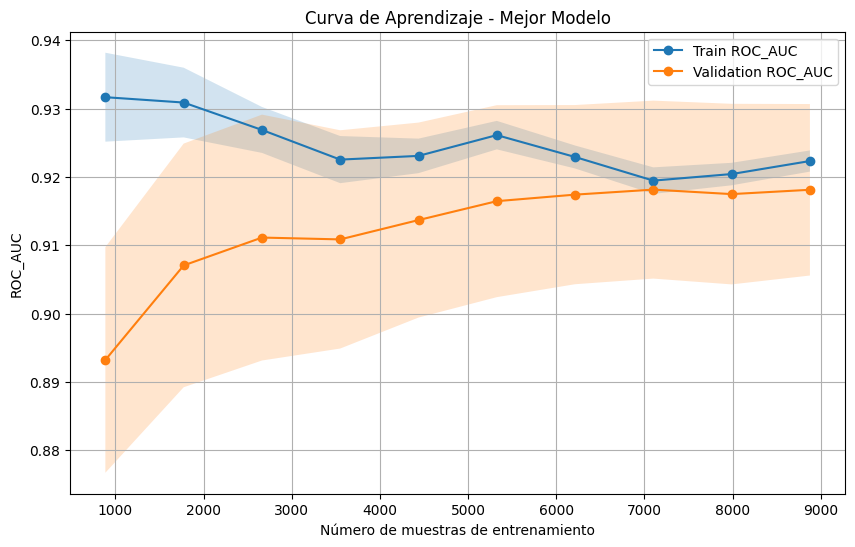

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Train ROC_AUC'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation ROC_AUC'
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel('Número de muestras de entrenamiento')
plt.ylabel('ROC_AUC')
plt.title('Curva de Aprendizaje - Mejor Modelo')
plt.legend()
plt.grid(True)

plt.show()

<Figure size 600x600 with 0 Axes>

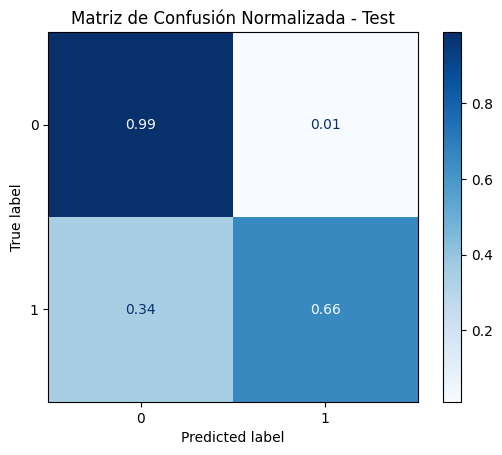

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================================================
# MATRIZ DE CONFUSIÓN NORMALIZADA EN TEST
# =========================================================

# predicciones del mejor modelo
y_test_pred = best_model.predict(X_test)

# matriz de confusión normalizada
cm = confusion_matrix(
    y_test,
    y_test_pred,
    normalize='true'
)

# visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 6))

disp.plot(
    cmap='Blues',
    values_format='.2f'
)

plt.title('Matriz de Confusión Normalizada - Test')

plt.show()

### GMM(Ricardo)

In [ ]:
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.mixture import GaussianMixture
from sklearn.utils.validation import check_X_y, check_array


class GMMClassifier(ClassifierMixin, BaseEstimator):

    def __init__(
        self,
        n_components=1,
        covariance_type='full',
        max_iter=100,
        n_init=1,
        init_params='kmeans',
        random_state=None
    ):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.max_iter = max_iter
        self.n_init = n_init
        self.init_params = init_params
        self.random_state = random_state

    def __sklearn_tags__(self):

        tags = super().__sklearn_tags__()

        tags.estimator_type = "classifier"

        return tags

    def fit(self, X, y):

        X, y = check_X_y(X, y)

        self.classes_ = np.unique(y)

        self.models_ = {}

        self.priors_ = {}

        for c in self.classes_:

            gmm = GaussianMixture(
                n_components=self.n_components,
                covariance_type=self.covariance_type,
                max_iter=self.max_iter,
                n_init=self.n_init,
                init_params=self.init_params,
                random_state=self.random_state
            )

            X_class = X[y == c]

            gmm.fit(X_class)

            self.models_[c] = gmm

            self.priors_[c] = X_class.shape[0] / X.shape[0]

        return self

    def predict_proba(self, X):

        X = check_array(X)

        log_probs = np.zeros(
            (X.shape[0], len(self.classes_))
        )

        for idx, c in enumerate(self.classes_):

            gmm = self.models_[c]

            log_likelihood = gmm.score_samples(X)

            log_prior = np.log(self.priors_[c])

            log_probs[:, idx] = (
                log_likelihood + log_prior
            )

        log_probs -= log_probs.max(
            axis=1,
            keepdims=True
        )

        probs = np.exp(log_probs)

        probs /= probs.sum(
            axis=1,
            keepdims=True
        )

        return probs

    def predict(self, X):

        probs = self.predict_proba(X)

        return self.classes_[
            np.argmax(probs, axis=1)
        ]

In [ ]:
pipeline_gmm = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('gmm', GMMClassifier(
        random_state=42
    ))
])

In [ ]:
param_grid_gmm = {
    'smote__sampling_strategy': [0.22, 0.3,],
    'gmm__n_components': [1, 2, 3, 4],
    'gmm__covariance_type': ['full', 'diag', 'tied', 'spherical'],
    'gmm__max_iter': [100, 200],
    'gmm__n_init': [1, 2],
    'gmm__init_params': [
        'kmeans',
        'k-means++',
        'random',
        'random_from_data'
    ],
}

In [ ]:
grid_gmm = GridSearchCV(
    estimator=pipeline_gmm,
    param_grid=param_grid_gmm,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    error_score='raise',
    return_train_score=True
)

In [ ]:
grid_gmm.fit(X_train, y_train)

Fitting 10 folds for each of 512 candidates, totalling 5120 fits
[CV] END gmm__covariance_type=full, gmm__init_params=kmeans, gmm__max_iter=100, gmm__n_components=1, gmm__n_init=1, smote__sampling_strategy=0.22; total time=   0.1s
[CV] END gmm__covariance_type=full, gmm__init_params=kmeans, gmm__max_iter=100, gmm__n_components=1, gmm__n_init=1, smote__sampling_strategy=0.3; total time=   0.1s
[CV] END gmm__covariance_type=full, gmm__init_params=kmeans, gmm__max_iter=100, gmm__n_components=1, gmm__n_init=1, smote__sampling_strategy=0.3; total time=   0.2s
[CV] END gmm__covariance_type=full, gmm__init_params=kmeans, gmm__max_iter=100, gmm__n_components=1, gmm__n_init=2, smote__sampling_strategy=0.22; total time=   0.2s
[CV] END gmm__covariance_type=full, gmm__init_params=kmeans, gmm__max_iter=100, gmm__n_components=1, gmm__n_init=2, smote__sampling_strategy=0.22; total time=   0.2s
[CV] END gmm__covariance_type=full, gmm__init_params=kmeans, gmm__max_iter=100, gmm__n_components=1, gmm__n

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gmm__covariance_type': ['full', 'diag', ...], 'gmm__init_params': ['kmeans', 'k-means++', ...], 'gmm__max_iter': [100, 200], 'gmm__n_components': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the highe


[CV] END gmm__covariance_type=tied, gmm__init_params=k-means++, gmm__max_iter=100, gmm__n_components=1, gmm__n_init=1, smote__sampling_strategy=0.22; total time=   0.1s
[CV] END gmm__covariance_type=tied, gmm__init_params=k-means++, gmm__max_iter=100, gmm__n_components=1, gmm__n_init=1, smote__sampling_strategy=0.3; total time=   0.1s
[CV] END gmm__covariance_type=tied, gmm__init_params=k-means++, gmm__max_iter=100, gmm__n_components=1, gmm__n_init=1, smote__sampling_strategy=0.3; total time=   0.1s
[CV] END gmm__covariance_type=tied, gmm__init_params=k-means++, gmm__max_iter=100, gmm__n_components=1, gmm__n_init=2, smote__sampling_strategy=0.22; total time=   0.2s
[CV] END gmm__covariance_type=tied, gmm__init_params=k-means++, gmm__max_iter=100, gmm__n_components=1, gmm__n_init=2, smote__sampling_strategy=0.22; total time=   0.2s
[CV] END gmm__covariance_type=tied, gmm__init_params=k-means++, gmm__max_iter=100, gmm__n_components=1, gmm__n_init=2, smote__sampling_strategy=0.22; total 

In [ ]:
results = pd.DataFrame(grid_gmm.cv_results_)

results_sorted = results.sort_values(
    by='mean_test_score',
    ascending=False
).reset_index(drop=True)

In [ ]:
top_3_results = []

for i in range(3):

    row = results_sorted.iloc[i]

    params = row['params']

    # reconstruir modelo
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('gmm', GMMClassifier(
            random_state=42
        ))
    ])

    model.set_params(**params)

    # entrenar
    model.fit(X_train, y_train)

    # probabilidades
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # métricas
    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)

    top_3_results.append({
        'rank': i + 1,
        'params': params,
        'train_roc_auc': train_auc,
        'validation_roc_auc': row['mean_test_score'],
        'test_roc_auc': test_auc
    })


In [ ]:
top_3_df = pd.DataFrame(top_3_results)

print("\n===== TOP 3 MODELOS GMM =====\n")
print(top_3_df)


===== TOP 3 MODELOS GMM =====

   rank                                             params  train_roc_auc  \
0     1  {'gmm__covariance_type': 'spherical', 'gmm__in...       0.891511   
1     2  {'gmm__covariance_type': 'spherical', 'gmm__in...       0.891511   
2     3  {'gmm__covariance_type': 'spherical', 'gmm__in...       0.891511   

   validation_roc_auc  test_roc_auc  
0            0.886342      0.881459  
1            0.886342      0.881459  
2            0.886342      0.881459  


In [ ]:
best_model = grid_gmm.best_estimator_

print("\n===== MEJOR MODELO =====\n")
print(grid_gmm.best_params_)
print(f"Best Validation ROC_AUC: {grid_gmm.best_score_:.4f}")


===== MEJOR MODELO =====

{'gmm__covariance_type': 'spherical', 'gmm__init_params': 'kmeans', 'gmm__max_iter': 100, 'gmm__n_components': 1, 'gmm__n_init': 1, 'smote__sampling_strategy': 0.3}
Best Validation ROC_AUC: 0.8863


In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# medias
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

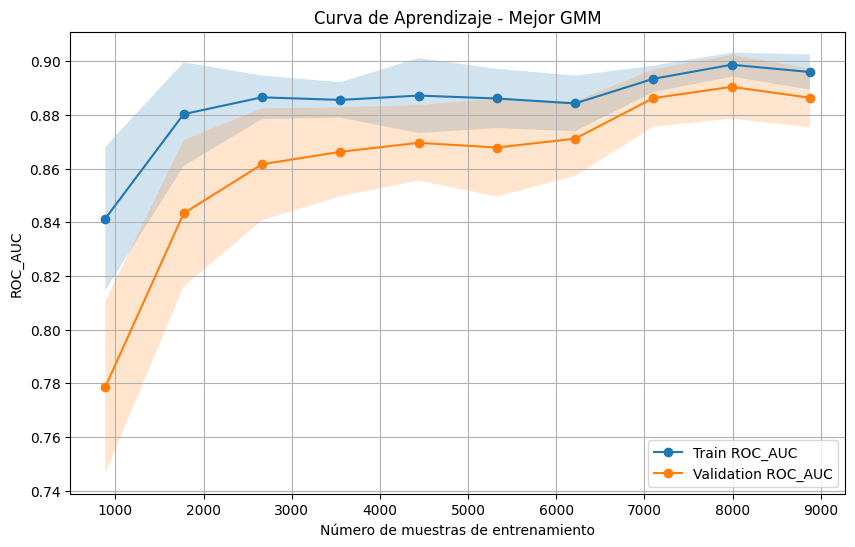

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Train ROC_AUC'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation ROC_AUC'
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel('Número de muestras de entrenamiento')
plt.ylabel('ROC_AUC')
plt.title('Curva de Aprendizaje - Mejor GMM')
plt.legend()
plt.grid(True)

plt.show()

<Figure size 600x600 with 0 Axes>

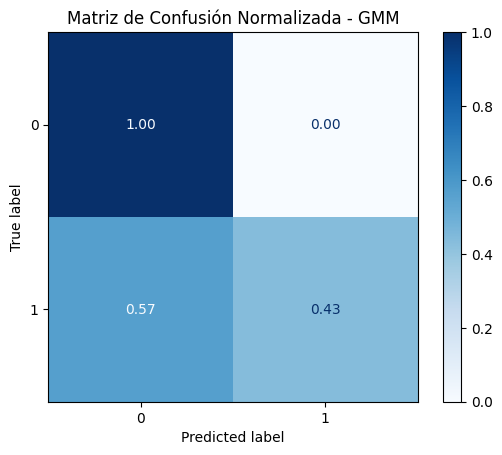

In [ ]:
y_test_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_test_pred,
    normalize='true'
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6, 6))

disp.plot(
    cmap='Blues',
    values_format='.2f'
)

plt.title('Matriz de Confusión Normalizada - GMM')

plt.show()

#Reducción de Dimensión

#Debe haber ejecutado el notebook principal hasta obtener X_train, X_test, y_train, y_test, best_rf y best_xgb.

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Instalar UMAP si no está disponible
try:
    import umap
    print("UMAP ya está instalado.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn", "-q"])
    import umap
    print("UMAP instalado correctamente.")

print("Librerías cargadas correctamente.")

UMAP ya está instalado.
Librerías cargadas correctamente.


In [89]:
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Variables originales: {X_train.shape[1]}")

X_train: (9864, 65)
X_test:  (2466, 65)
Variables originales: 65


#Análisis Individual de Variables

In [91]:
# ─── Correlación de Pearson (variables numéricas) ───────────────────────────
y_train_flat = np.array(y_train).ravel()
y_series = pd.Series(y_train_flat, name='Revenue')
X_train_df = pd.DataFrame(X_train, columns=X_train.columns if hasattr(X_train, 'columns') else [f'f{i}' for i in range(X_train.shape[1])])

pearson_corr = X_train_df.corrwith(y_series).abs().sort_values(ascending=False)

print("=" * 55)
print("CORRELACIÓN DE PEARSON |r| con Revenue (descendente)")
print("=" * 55)
print(pearson_corr.to_string())

CORRELACIÓN DE PEARSON |r| con Revenue (descendente)
Region__7                         0.023433
Browser__12                       0.021510
TrafficType__11                   0.017481
Browser__1                        0.015592
ProductRelated_Duration           0.014731
SpecialDay                        0.014447
Browser__4                        0.014399
Browser__8                        0.013899
OperatingSytem__1                 0.013657
OperatingSytem__3                 0.013569
TrafficType__6                    0.013386
OperatingSytem__8                 0.013321
Region__8                         0.013060
Browser__2                        0.012953
Browser__5                        0.012806
ProductRelated                    0.012441
Browser__6                        0.011775
TrafficType__15                   0.010965
TrafficType__3                    0.010876
Region__2                         0.010034
Browser__11                       0.009622
OperatingSytem__5                 0.009622
V

In [92]:
# ─── Information Value (IV) ──────────────────────────────────────────────────
def compute_iv(X_df, y, n_bins=10):
    """
    Calcula el Information Value para cada variable.
    Variables continuas se discretizan en cuantiles.
    """
    iv_dict = {}
    y = np.array(y)
    total_pos = y.sum()
    total_neg = len(y) - total_pos

    for col in X_df.columns:
        x = X_df[col].values
        n_unique = len(np.unique(x))

        # Discretizar variables continuas en cuantiles
        if n_unique > n_bins:
            try:
                bins = pd.qcut(x, q=n_bins, duplicates='drop', labels=False)
            except Exception:
                bins = pd.cut(x, bins=n_bins, labels=False)
        else:
            bins = x

        iv = 0.0
        for b in np.unique(bins):
            mask = (bins == b)
            n_pos = y[mask].sum()
            n_neg = mask.sum() - n_pos

            dist_pos = (n_pos + 0.5) / (total_pos + 0.5)
            dist_neg = (n_neg + 0.5) / (total_neg + 0.5)
            woe = np.log(dist_pos / dist_neg)
            iv += (dist_pos - dist_neg) * woe

        iv_dict[col] = iv

    return pd.Series(iv_dict).sort_values(ascending=False)


iv_series = compute_iv(X_train_df, y_train)

print("=" * 55)
print("INFORMATION VALUE (IV) por variable (descendente)")
print("=" * 55)
print(iv_series.to_string())
print("\nEscala de referencia IV:")
print("  < 0.02 → nulo/inútil | 0.02–0.1 → débil | 0.1–0.3 → medio | >0.3 → fuerte")

INFORMATION VALUE (IV) por variable (descendente)
PageValues                        2.428687
ExitRates                         0.863661
BounceRates                       0.522602
ProductRelated_Duration           0.495924
ProductRelated                    0.424999
Administrative_Duration           0.242291
Month                             0.232119
Administrative                    0.162155
TrafficType__2                    0.115694
SpecialDay                        0.105208
VisitorType__New_Visitor          0.067912
VisitorType__Returning_Visitor    0.067033
TrafficType__3                    0.066187
Informational_Duration            0.056979
Informational                     0.053792
TrafficType__1                    0.047150
TrafficType__13                   0.041582
OperatingSytem__3                 0.040953
OperatingSytem__2                 0.031233
TrafficType__8                    0.019470
TrafficType__15                   0.009266
Weekend                           0.008953
Brow

# Tabla de candidatas a eliminación

In [93]:
summary_df = pd.DataFrame({
    'Pearson_abs': pearson_corr,
    'IV': iv_series
}).dropna()

# Umbral de eliminación
PEARSON_THRESHOLD = 0.05
IV_THRESHOLD = 0.02

summary_df['Candidata_eliminacion'] = (
    (summary_df['Pearson_abs'] < PEARSON_THRESHOLD) &
    (summary_df['IV'] < IV_THRESHOLD)
)

candidatas = summary_df[summary_df['Candidata_eliminacion']].index.tolist()

print("=" * 60)
print("TABLA RESUMEN – Análisis Individual de Variables")
print("=" * 60)
print(summary_df.sort_values('IV', ascending=False).to_string())
print(f"\n>>> Candidatas a eliminación ({len(candidatas)} variables):")
for v in candidatas:
    print(f"    - {v}")

TABLA RESUMEN – Análisis Individual de Variables
                                Pearson_abs        IV  Candidata_eliminacion
PageValues                         0.000794  2.428687                  False
ExitRates                          0.003044  0.863661                  False
BounceRates                        0.001216  0.522602                  False
ProductRelated_Duration            0.014731  0.495924                  False
ProductRelated                     0.012441  0.424999                  False
Administrative_Duration            0.005436  0.242291                  False
Month                              0.001952  0.232119                  False
Administrative                     0.008778  0.162155                  False
TrafficType__2                     0.001444  0.115694                  False
SpecialDay                         0.014447  0.105208                  False
VisitorType__New_Visitor           0.009245  0.067912                  False
VisitorType__Returning_Visi

# Visualización: heatmap de correlación (top 20) y barras IV

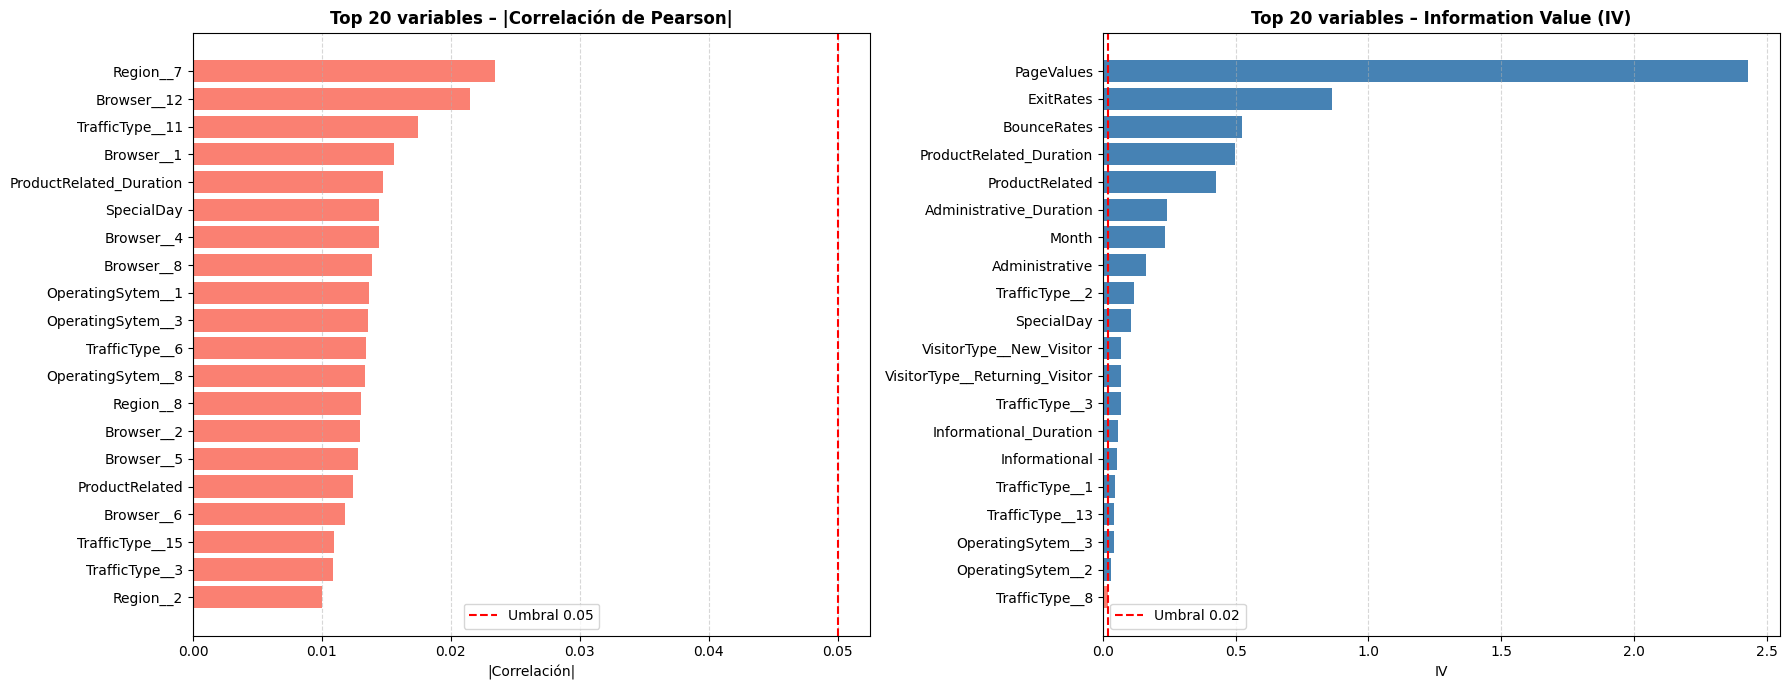

Gráfica guardada en: 5_1_analisis_variables.png


In [94]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barras – Pearson
top20_pearson = pearson_corr.head(20)
colors_p = ['steelblue' if v >= PEARSON_THRESHOLD else 'salmon' for v in top20_pearson]
axes[0].barh(top20_pearson.index[::-1], top20_pearson.values[::-1], color=colors_p[::-1])
axes[0].axvline(PEARSON_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Umbral {PEARSON_THRESHOLD}')
axes[0].set_title('Top 20 variables – |Correlación de Pearson|', fontweight='bold')
axes[0].set_xlabel('|Correlación|')
axes[0].legend()
axes[0].grid(True, axis='x', linestyle='--', alpha=0.5)

# Barras – IV
top20_iv = iv_series.head(20)
colors_iv = ['steelblue' if v >= IV_THRESHOLD else 'salmon' for v in top20_iv]
axes[1].barh(top20_iv.index[::-1], top20_iv.values[::-1], color=colors_iv[::-1])
axes[1].axvline(IV_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Umbral {IV_THRESHOLD}')
axes[1].set_title('Top 20 variables – Information Value (IV)', fontweight='bold')
axes[1].set_xlabel('IV')
axes[1].legend()
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('5_1_analisis_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada en: 5_1_analisis_variables.png")

#Extracción de Características Lineal – PCA

# Análisis de varianza explicada por PCA

In [95]:
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled  = scaler_pca.transform(X_test)

n_vars = X_train_scaled.shape[1]
pca_full = PCA(n_components=n_vars, random_state=42)
pca_full.fit(X_train_scaled)

varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)

# Número de componentes para ≥ 95% de varianza
VARIANZA_OBJETIVO = 0.95
n_componentes_pca = int(np.argmax(varianza_acum >= VARIANZA_OBJETIVO)) + 1
reduccion_pca = round((1 - n_componentes_pca / n_vars) * 100, 1)

print(f"Variables originales:        {n_vars}")
print(f"Componentes PCA (≥95% var):  {n_componentes_pca}")
print(f"Varianza explicada:          {varianza_acum[n_componentes_pca-1]*100:.2f}%")
print(f"Porcentaje de reducción:     {reduccion_pca}%")

Variables originales:        65
Componentes PCA (≥95% var):  50
Varianza explicada:          95.51%
Porcentaje de reducción:     23.1%


# Gráfica de varianza explicada

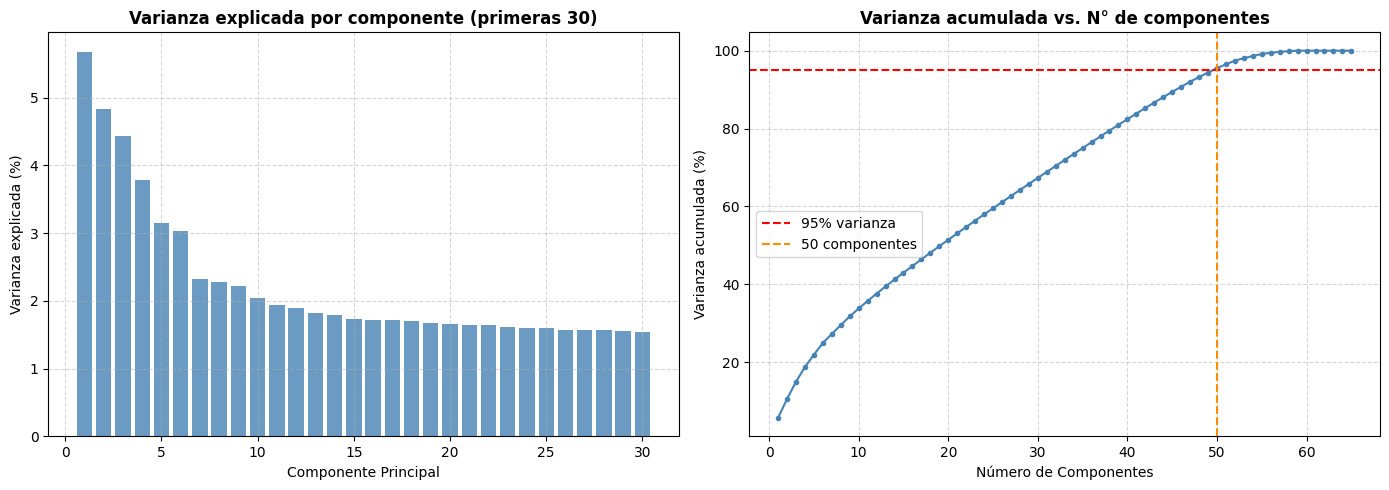

Gráfica guardada en: 5_2_pca_varianza.png


In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, min(31, n_vars+1)),
            pca_full.explained_variance_ratio_[:30] * 100,
            color='steelblue', alpha=0.8)
axes[0].set_title('Varianza explicada por componente (primeras 30)', fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(range(1, n_vars+1), varianza_acum * 100, 'o-', color='steelblue', markersize=3)
axes[1].axhline(95, color='red', linestyle='--', label='95% varianza')
axes[1].axvline(n_componentes_pca, color='darkorange', linestyle='--',
                label=f'{n_componentes_pca} componentes')
axes[1].set_title('Varianza acumulada vs. N° de componentes', fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('5_2_pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada en: 5_2_pca_varianza.png")

# Transformación PCA con n componentes seleccionados

In [97]:
pca = PCA(n_components=n_componentes_pca, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Shape train PCA: {X_train_pca.shape}")
print(f"Shape test  PCA: {X_test_pca.shape}")

Shape train PCA: (9864, 50)
Shape test  PCA: (2466, 50)


# CV StratifiedKFold reutilizado

In [98]:
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Función auxiliar para calcular todas las métricas
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, cv):
    modelo.fit(X_tr, y_tr)
    y_pred       = modelo.predict(X_te)
    y_pred_proba = modelo.predict_proba(X_te)[:, 1]

    cv_auc = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)

    return {
        'Modelo': nombre,
        'ROC-AUC CV (media)': round(cv_auc.mean(), 4),
        'ROC-AUC CV (std)': round(cv_auc.std(), 4),
        'ROC-AUC Test': round(roc_auc_score(y_te, y_pred_proba), 4),
        'Accuracy Test': round(accuracy_score(y_te, y_pred), 4),
        'F1 Test': round(f1_score(y_te, y_pred), 4),
        'Precision Test': round(precision_score(y_te, y_pred), 4),
        'Recall Test': round(recall_score(y_te, y_pred), 4),
    }

# RF con PCA

In [99]:
# Se extraen los mejores hiperparámetros del RF (sin reducción)
# y se re-entrena sobre los componentes PCA.

best_params_rf = grid_rf.best_params_   # del notebook principal

rf_pca = ImbPipeline([
    ('smote', SMOTE(
        random_state=42,
        sampling_strategy=best_params_rf.get('smote__sampling_strategy', 0.3),
        k_neighbors=best_params_rf.get('smote__k_neighbors', 5)
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=best_params_rf.get('classifier__n_estimators', 200),
        max_depth=best_params_rf.get('classifier__max_depth', 10),
        min_samples_leaf=best_params_rf.get('classifier__min_samples_leaf', 1),
        max_features=best_params_rf.get('classifier__max_features', 'sqrt'),
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

resultado_rf_pca = evaluar_modelo(
    f'RF + PCA ({n_componentes_pca} comp)',
    rf_pca, X_train_pca, y_train, X_test_pca, y_test, cv_strategy
)
print(resultado_rf_pca)

{'Modelo': 'RF + PCA (50 comp)', 'ROC-AUC CV (media)': np.float64(0.8675), 'ROC-AUC CV (std)': np.float64(0.0166), 'ROC-AUC Test': np.float64(0.8432), 'Accuracy Test': 0.8731, 'F1 Test': 0.4943, 'Precision Test': 0.6456, 'Recall Test': 0.4005}


# XGBoost con PCA

In [100]:
best_params_xgb = grid_xgb.best_params_   # del notebook principal

xgb_pca = ImbPipeline([
    ('smote', SMOTE(
        random_state=42,
        sampling_strategy=best_params_xgb.get('smote__sampling_strategy', 0.3),
        k_neighbors=best_params_xgb.get('smote__k_neighbors', 5)
    )),
    ('classifier', XGBClassifier(
        n_estimators=best_params_xgb.get('classifier__n_estimators', 200),
        max_depth=best_params_xgb.get('classifier__max_depth', 6),
        learning_rate=best_params_xgb.get('classifier__learning_rate', 0.1),
        subsample=best_params_xgb.get('classifier__subsample', 0.8),
        colsample_bytree=best_params_xgb.get('classifier__colsample_bytree', 0.8),
        eval_metric='logloss',
        verbosity=0,
        random_state=42,
        n_jobs=-1
    ))
])

resultado_xgb_pca = evaluar_modelo(
    f'XGBoost + PCA ({n_componentes_pca} comp)',
    xgb_pca, X_train_pca, y_train, X_test_pca, y_test, cv_strategy
)
print(resultado_xgb_pca)

{'Modelo': 'XGBoost + PCA (50 comp)', 'ROC-AUC CV (media)': np.float64(0.8779), 'ROC-AUC CV (std)': np.float64(0.0134), 'ROC-AUC Test': np.float64(0.8554), 'Accuracy Test': 0.8779, 'F1 Test': 0.5106, 'Precision Test': 0.6738, 'Recall Test': 0.411}
